In [85]:
import folium
import pandas as pd 
from scrapper.AlquilerScrapper import Scrapper
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm


Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [165]:
df = pd.read_csv("storage/arg_venta_data.csv")

df.isna().sum()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                917 non-null    int64  
 1   url               917 non-null    object 
 2   precio            917 non-null    object 
 3   expensas          538 non-null    object 
 4   area_m2           911 non-null    object 
 5   dormitorios       795 non-null    object 
 6   antiguedad        659 non-null    object 
 7   tipo_inmueble     917 non-null    object 
 8   puntaje_arg_prop  917 non-null    int64  
 9   imagen_path       914 non-null    object 
 10  image_url         917 non-null    object 
 11  lat               914 non-null    float64
 12  lon               914 non-null    float64
 13  valido_desde      917 non-null    object 
 14  valido_hasta      0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 107.6+ KB


In [87]:
df = df[ df["lat"].notna() & df["lon"].notna() ]
df.info()
df[['lat','lon']].value_counts().head(100)


<class 'pandas.core.frame.DataFrame'>
Index: 914 entries, 0 to 916
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                914 non-null    int64  
 1   url               914 non-null    object 
 2   precio            914 non-null    object 
 3   expensas          538 non-null    object 
 4   area_m2           908 non-null    object 
 5   dormitorios       792 non-null    object 
 6   antiguedad        659 non-null    object 
 7   tipo_inmueble     914 non-null    object 
 8   puntaje_arg_prop  914 non-null    int64  
 9   imagen_path       911 non-null    object 
 10  image_url         914 non-null    object 
 11  lat               914 non-null    float64
 12  lon               914 non-null    float64
 13  valido_desde      914 non-null    object 
 14  valido_hasta      0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 114.2+ KB


lat        lon      
-34.57157  -58.45650    8
-34.62783  -58.43353    7
-34.57619  -58.49572    7
-34.63902  -58.37528    6
-34.57336  -58.48043    6
                       ..
-34.59275  -58.37940    1
-34.59280  -58.42995    1
-34.58738  -58.41375    1
-34.59000  -58.43400    1
-34.58718  -58.48194    1
Name: count, Length: 100, dtype: int64

<Axes: >

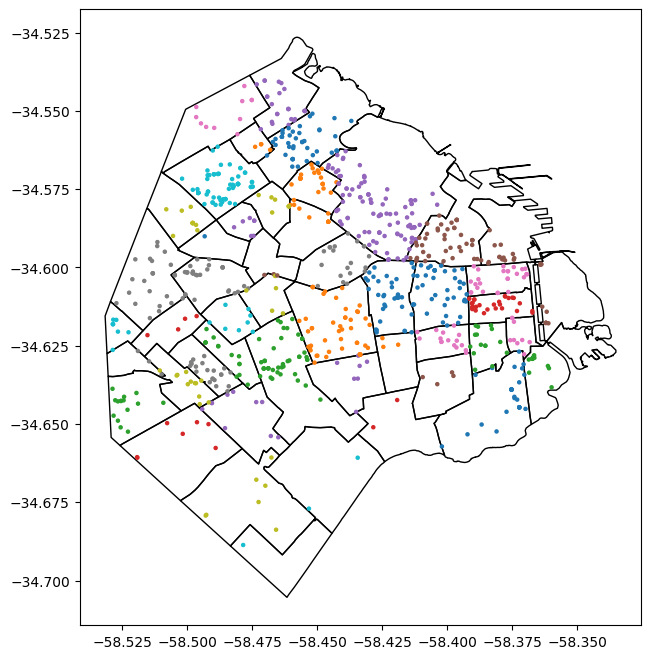

In [142]:


# Barrios
barrios = gpd.read_file("barrios.geojson")

# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf_join = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_join = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf_join.plot(
    ax=ax,
    column='nombre',
    markersize=5,
    legend=False
)


Elimino barrios con menos de 5 datos

In [89]:
gdf_join = gdf_join[
    gdf_join.groupby('nombre')['nombre'].transform('size') >= 5
]


La columna "dormitorios" tiene valores nulos cuando son monoambientes y valores del tipo string "1 dorm. , 2 dorm, etc" cuando no es monoambinete. Por esta razón, se emplea una nueva columna "ambientes" que contabiliza la cantidad de ambientes en función de los dormitorios y lo transforma en un numero entero.

In [90]:
gdf_join['dormitorios'] = gdf_join['dormitorios'].fillna(0)
gdf_join['ambientes'] = gdf_join['dormitorios'].astype(str).str.extract('(\d+)').astype(int) + 1
gdf_join['ambientes']

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0      1
1      3
2      3
3      3
4      2
      ..
912    3
913    2
914    1
915    1
916    2
Name: ambientes, Length: 884, dtype: int32

Vemos si hay dptos sin infor de superficie cubierta en m^2. En ese caso, rellenamos este dato con la mediana de los departamentos con esa cantidad de ambientes. El resto será descartado.

In [91]:

# convert area_m2 to numeric (extract numbers, handle commas and coercion)
gdf_join['area_m2'] = (
    gdf_join['area_m2']
    .astype(str)
    .str.extract(r'(\d+(?:[\.,]\d+)?)', expand=False)
    .str.replace(',', '.', regex=False)
)
gdf_join['area_m2'] = pd.to_numeric(gdf_join['area_m2'], errors='coerce')

mask = gdf_join['area_m2'].isna() & gdf_join['ambientes'].notna()

gdf_join.loc[mask, 'area_m2'] = (
    gdf_join.groupby('ambientes')['area_m2']
      .transform('median')
      .loc[mask]
)

print("cantidad de nulos en area_m2:", gdf_join['area_m2'].isna().sum())

cantidad de nulos en area_m2: 0


In [92]:
gdf_join['expensas'] = (
    gdf_join['expensas']
        .str.extract(r'\$\s*([\d\.]+)')[0]   # toma 350.000
        .str.replace('.', '', regex=False)  # borra separador de miles
        .astype('float')
)


gdf_join['expensas'] = pd.to_numeric(gdf_join['expensas'], errors='coerce')

print("cantidad de nulos en expensas:", gdf_join['expensas'].isna().sum())

gdf_join['expensas'].fillna(0, inplace=True)

cantidad de nulos en expensas: 359
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




In [93]:
gdf_join['precio']

0       USD 69.500 + $105.000 expensas
1                          USD 320.000
2       USD 84.900 + $110.000 expensas
3      USD 120.000 + $258.000 expensas
4       USD 58.000 + $142.000 expensas
                    ...               
912                        USD 201.500
913                        USD 108.000
914                         USD 89.495
915                         USD 95.374
916                        USD 119.900
Name: precio, Length: 884, dtype: object

In [94]:
print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())

gdf_join["precio"] = gdf_join["precio"].str.findall(
    r"(?i)(usd|u\$s|\$)\s*([\d\.]+)"
)

print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())
gdf_join['precio'].where(gdf_join['precio'].isna(), None)



cantidad de nulos en precio: 0
cantidad de nulos en precio: 0


0      None
1      None
2      None
3      None
4      None
       ... 
912    None
913    None
914    None
915    None
916    None
Name: precio, Length: 884, dtype: object

Me quedo solo con el precio del alquiler. Los percios en dolar los transformo a pesos scrapeando el valor de ambitofinanciero
Borro los valores de alquiler menores a $100k por ser demasiado bajos

In [95]:
gdf_join['precio']

0       [(USD, 69.500), ($, 105.000)]
1                    [(USD, 320.000)]
2       [(USD, 84.900), ($, 110.000)]
3      [(USD, 120.000), ($, 258.000)]
4       [(USD, 58.000), ($, 142.000)]
                    ...              
912                  [(USD, 201.500)]
913                  [(USD, 108.000)]
914                   [(USD, 89.495)]
915                   [(USD, 95.374)]
916                  [(USD, 119.900)]
Name: precio, Length: 884, dtype: object

In [96]:

gdf_join["precio"] = gdf_join["precio"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 1 else (np.nan, np.nan)
)
gdf_join = gdf_join[~gdf_join['precio'].apply(lambda x: pd.isna(x[0]))]

valor_dolar_oficial_venta = pd.read_csv("storage/dolar_hoy.csv").iloc[0]['valor']

gdf_join['precio'] = gdf_join['precio'].apply(
    lambda x: float(x[1].replace('.', '')) / valor_dolar_oficial_venta if x[0].lower() in ['$', '$ '] else float(x[1].replace('.', ''))
)   

gdf_join['precio'] = pd.to_numeric(gdf_join['precio'], errors='coerce')

In [97]:
gdf_join = gdf_join.drop(gdf_join[gdf_join['precio'] <= 8000]['precio'].index)

Columna precio por metro cuadrádo 

In [98]:
gdf_join['precio_m2'] = gdf_join['precio'] / gdf_join['area_m2']


EDA

analicemos la relación entre el precio final y la cantidad de ambientes.
Quiero: tomar una zona con puntos parecidos y luego, para cada conjunto de ambientes estimar la relacion entre el precio y la superficie cubierta.
Si vemos que las tendencias son distintas para cada conjunto con ambientes, luego podría existir una dependencia con la cantidad de ambientes en el precio final. 
Por ejemplo, podría pasar que al tener menos demanda los departamentos con muchos ambientes, estos tiendan a no aumentar tanto el precio en relación a los que tinene menos ambientes en comparación al aumento de precio de tener 1 ambiente a 2 ambientes bajo la misme superficie cubierta.

In [99]:
densidad_naive = (
    gdf_join
    .groupby('nombre')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


nombre
Palermo          106
Villa Urquiza     70
Caballito         50
Recoleta          45
Flores            43
dtype: int64

In [100]:
gdf_palermo = gdf_join[ gdf_join['nombre'] == 'Palermo' ]
gdf_caballito = gdf_join[ gdf_join['nombre'] == 'Caballito' ]

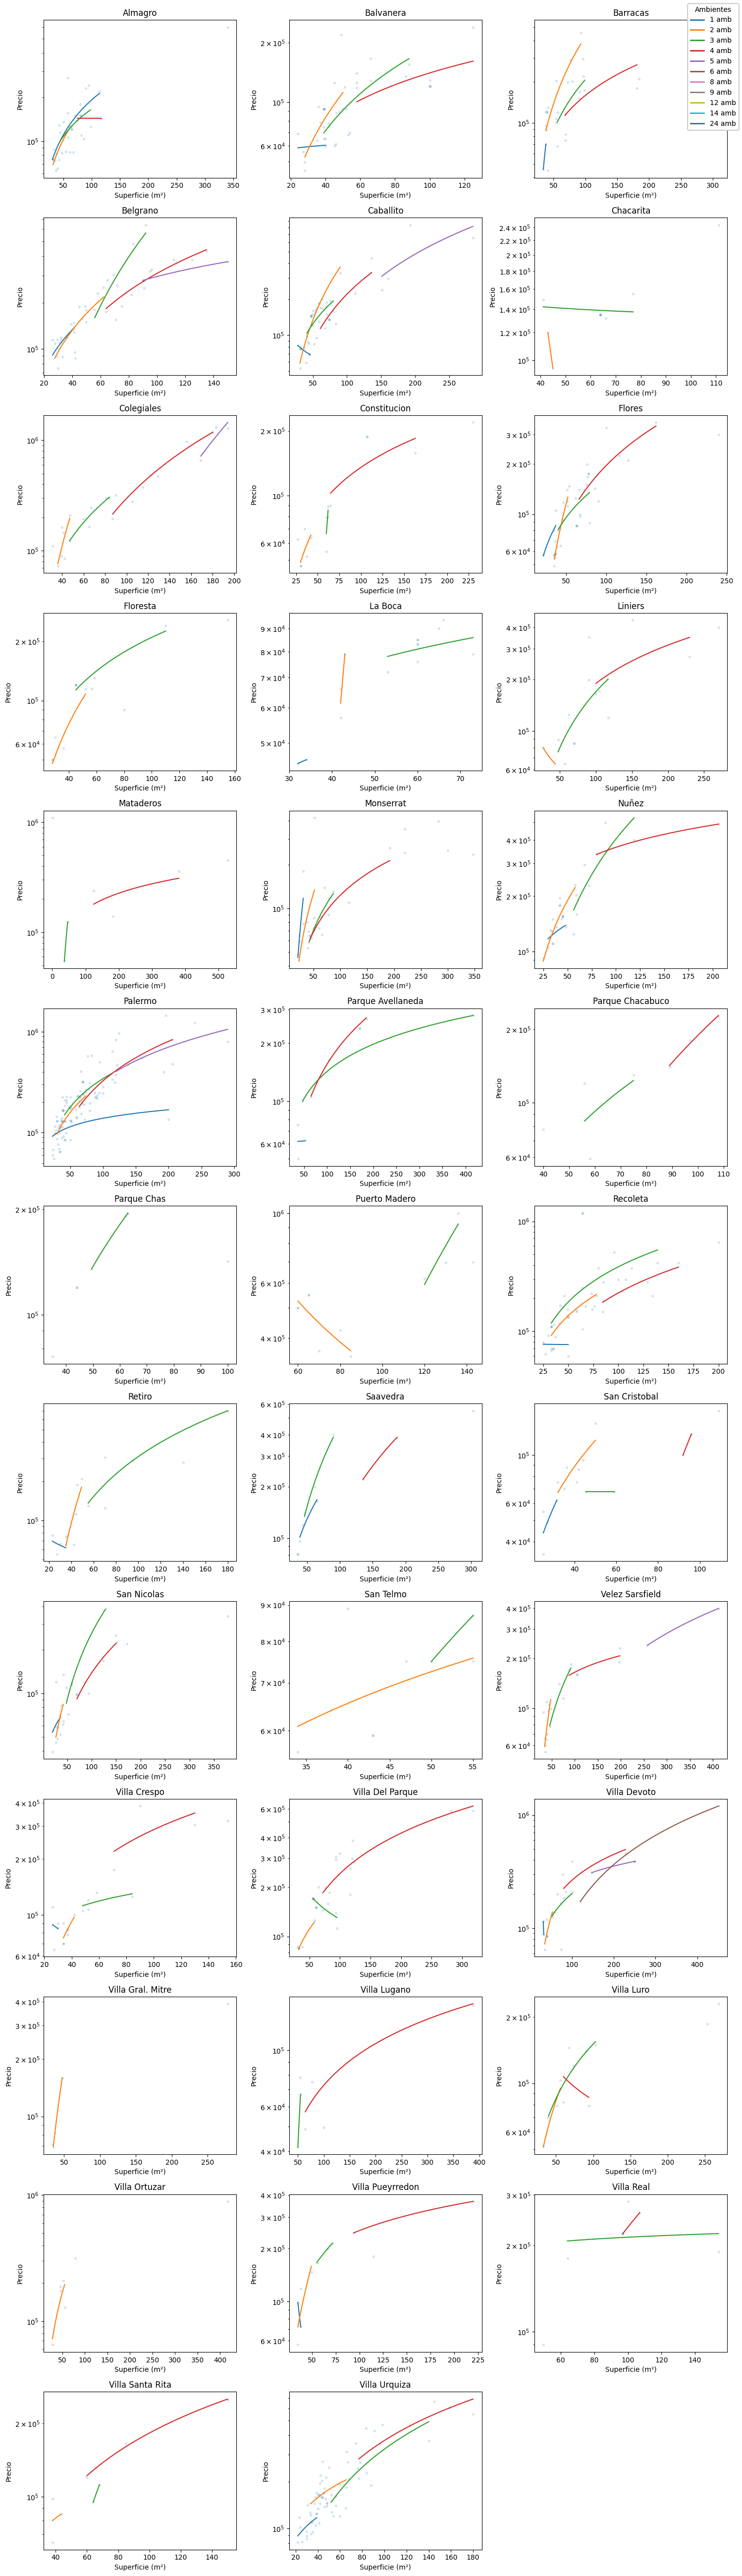

In [101]:
################## cambiar min obs ##################
min_obs = 1

barrios = (
    gdf_join
    .groupby('nombre')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf_join['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios):

    gdf_b = gdf_join[gdf_join['nombre'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2'],
        gdf_b['precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(np.log(sub['area_m2']))
        y = np.log(sub['precio'])

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2'].min(),
            sub['area_m2'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(np.log(x_grid))
        )

        ax.plot(
            x_grid,
            np.exp(y_hat),
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )


    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('Precio')
    ax.set_yscale('log')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [102]:
gdf_join['superficie_por_ambientes'] = gdf_join['area_m2'] / gdf_join['ambientes']

# analisis de antiguedad


In [103]:
gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,tipo_inmueble,puntaje_arg_prop,imagen_path,...,lon,valido_desde,valido_hasta,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes
0,8369836,https://www.argenprop.com/departamento-en-vent...,69500.0,105000.0,45.0,0,NaN,departamento,1,images/8369836.jpg,...,-58.45169,2026-01-17 17:05:21.567385,NaN,POINT (-58.45169 -34.60627),7.0,Caballito,6.0,1,1544.444444,45.000000
2,15860074,https://www.argenprop.com/departamento-en-vent...,84900.0,110000.0,63.0,2 dorm.,NaN,departamento,1,images/15860074.jpg,...,-58.46879,2026-01-17 17:05:21.597368,NaN,POINT (-58.46879 -34.63223),12.0,Flores,7.0,3,1347.619048,21.000000
3,18342065,https://www.argenprop.com/departamento-en-vent...,120000.0,258000.0,45.0,2 dorm.,NaN,departamento,1,images/18342065.jpg,...,-58.49293,2026-01-17 17:05:21.605364,NaN,POINT (-58.49293 -34.62398),13.0,Floresta,10.0,3,2666.666667,15.000000
4,18770885,https://www.argenprop.com/departamento-en-vent...,58000.0,142000.0,36.0,1 dorm.,NaN,departamento,1,images/18770885.jpg,...,-58.47018,2026-01-17 17:05:21.615360,NaN,POINT (-58.47018 -34.62986),12.0,Flores,7.0,2,1611.111111,18.000000
5,18700832,https://www.argenprop.com/departamento-en-vent...,150000.0,145100.0,61.0,2 dorm.,NaN,departamento,1,images/18700832.jpg,...,-58.50000,2026-01-17 17:05:21.625353,NaN,POINT (-58.5 -34.6016),36.0,Villa Del Parque,11.0,3,2459.016393,20.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,15774316,https://www.argenprop.com/departamento-en-vent...,95000.0,0.0,38.0,1 dorm.,NaN,departamento,1,images/15774316.jpg,...,-58.37230,2026-01-17 23:35:48.630505,NaN,POINT (-58.3723 -34.64469),3.0,Barracas,4.0,2,2500.000000,19.000000
913,15773972,https://www.argenprop.com/departamento-en-vent...,108000.0,0.0,54.0,1 dorm.,NaN,departamento,1,images/15773972.jpg,...,-58.37230,2026-01-17 23:35:48.712087,NaN,POINT (-58.3723 -34.64469),3.0,Barracas,4.0,2,2000.000000,27.000000
914,16449678,https://www.argenprop.com/departamento-en-vent...,89495.0,0.0,30.0,0,NaN,departamento,0,images/16449678.jpg,...,-58.49019,2026-01-17 23:35:48.741975,NaN,POINT (-58.49019 -34.57928),47.0,Villa Urquiza,12.0,1,2983.166667,30.000000
915,16449671,https://www.argenprop.com/departamento-en-vent...,95374.0,0.0,30.0,0,NaN,departamento,0,images/16449671.jpg,...,-58.49019,2026-01-17 23:35:48.766146,NaN,POINT (-58.49019 -34.57928),47.0,Villa Urquiza,12.0,1,3179.133333,30.000000


Extraigo datos antiguedad, relleno con la media del barrio cuando no esta precenta (a muchos a estrenar le estoy poniendo mal el dato, se tiene que corregir.)

In [104]:


gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .fillna(
        gdf_join
        .groupby('nombre')['antiguedad']
        .transform('mean')
    )
)

gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,tipo_inmueble,puntaje_arg_prop,imagen_path,...,lon,valido_desde,valido_hasta,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes


Variograma por log(precio)

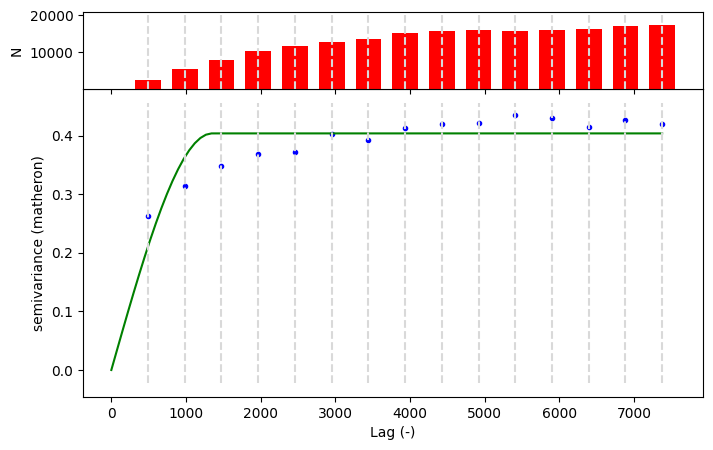

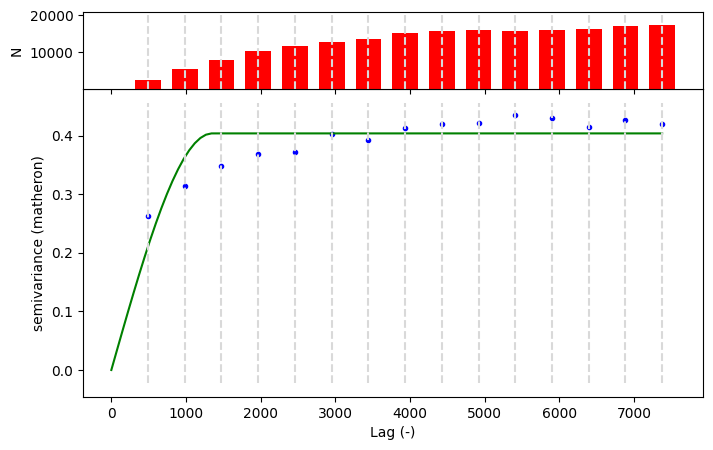

In [105]:


gdf = gdf_join.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = np.log(gdf['precio'].values)

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

One hot encoding de tipo de inmueble 

In [107]:
gdf = pd.get_dummies(
    gdf,
    columns=['tipo_inmueble'],
    drop_first=True  
).reset_index(drop=True)


# Formulamos y entrenamos modelo

Para cada barrio (si hay datos) vamos a ajustar un modelo geograficamente pesado local, dentro de cada barrio abran multiples modelos para las distintas cantidades 

In [108]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.preprocessing import StandardScaler
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import copy
from pykrige.ok import OrdinaryKriging


In [109]:
gdf.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'nombre', 'comuna', 'ambientes', 'precio_m2',
       'superficie_por_ambientes', 'tipo_inmueble_departamento',
       'tipo_inmueble_ph'],
      dtype='object')

In [129]:


class SpatialKernelPriceModel:
    def __init__(self, gdf: gpd.GeoDataFrame):
        self._check_data_validity(gdf)

        self.data = gdf
        self.bw_ = None
        self.results_ = None
        self.scaler_ = None   # <-- clave

    # ----------------------------
    # Validaciones
    # ----------------------------
    def _check_data_validity(self, data):
        if not isinstance(data, gpd.GeoDataFrame):
            raise TypeError("Input data must be a GeoDataFrame")

        if data.crs is None:
            raise ValueError("GeoDataFrame must have a CRS defined")

        if data.crs.to_epsg() != 3857:
            raise ValueError(
                f"GeoDataFrame CRS must be EPSG:3857, got {data.crs}"
            )

        if not set(data.geometry.geom_type).issubset({"Point"}):
            raise ValueError("Geometry must be Point for spatial kernel models")

    # ----------------------------
    # Fit
    # ----------------------------
    def fit(self, data: gpd.GeoDataFrame):
        self._check_data_validity(data)
        self.data = data

        gdf = data

        # Coordenadas
        coords = np.column_stack([
            gdf.geometry.x,
            gdf.geometry.y
        ])

        # Variable respuesta (log-precio)
        y = np.log(gdf['precio'].values).reshape(-1, 1)

        # Covariables
        X = gdf[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        # -------- Normalización --------
        self.scaler_ = StandardScaler()
        X_std = self.scaler_.fit_transform(X)

        # -------- Selección de bandwidth --------
        bw_selector = Sel_BW(
            coords,
            y,
            X_std,
            spherical=False
        )

        bw = bw_selector.search()

        # -------- GWR --------
        self.gwr_ = GWR(
            coords,
            y,
            X_std,
            bw=bw,
            fixed=False,
            kernel='bisquare'
        )

        self.results_ = self.gwr_.fit()
        self.bw_ = bw

        return self.results_

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, gdf_new: gpd.GeoDataFrame):
        if self.gwr_ is None or self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        self._check_data_validity(gdf_new)

        coords_new = np.column_stack([
            gdf_new.geometry.x,
            gdf_new.geometry.y
        ])

        X_new = gdf_new[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        X_new_std = self.scaler_.transform(X_new)

        gwr_for_pred = copy.deepcopy(self.gwr_)

        preds = gwr_for_pred.predict(
            coords_new,
            X_new_std
        )

        log_preds = preds.predictions.flatten()


        return np.exp(log_preds)


    # ----------------------------
    # Summary
    # ----------------------------
    def summary(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        print(self.results_.summary())
        return self.results_.summary()
    
    def results(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")
        return self.results_

In [130]:
gdf = gdf.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.2,
    random_state=42
)

In [131]:

model = SpatialKernelPriceModel(gdf)

model.fit(
    data=gdf_train,
)


In [135]:
model.summary()

Model type                                                         Gaussian
Number of observations:                                                 704
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            150.760
Log-likelihood:                                                    -456.469
AIC:                                                                922.939
AICc:                                                               925.059
BIC:                                                              -4432.428
R2:                                                                   0.511
Adj. R2:                                                              0.509

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [136]:
# Predicción en log (como sale del GWR)
y_test_pred = model.predict(
        gdf_test
)

y_test_true = gdf_test['precio'].values
rmse_price = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred
))

rmse_price



2098451.9646043614

In [137]:
(y_test_true <= 0).sum()
y_test_true.min(), y_test_true.max()
y_test_pred.min(), y_test_pred.max()

(47837.182348047165, 28347006.551791262)

In [138]:
res = model.results()
res.tvalues


array([[ 1.56903142e+02, -2.79198934e+00,  2.88936510e+00,
         2.96368343e+00,  1.46884340e+00],
       [ 1.64857379e+02, -1.46817372e+00, -1.13769501e-01,
         4.00978555e+00, -8.38761175e-02],
       [ 1.76733647e+02, -2.47788258e+00,  2.73899152e-01,
         4.13975778e+00, -5.66546757e-02],
       ...,
       [ 1.99536446e+02, -2.47639757e+00,  1.89545369e-01,
         4.47726880e+00,  1.52655718e-02],
       [ 2.05557690e+02, -4.20662486e+00,  2.95355645e+00,
         1.38035443e+00,  1.14238635e+00],
       [ 2.10438057e+02, -2.99095757e+00,  1.89603676e+00,
         4.05330073e+00,  1.10100405e+00]])

In [148]:

var_names = ['antiguedad', 'ambientes', 'area_m2', 'expensas']

coefs = pd.DataFrame(
    res.params[:, 1:],   # saco intercepto
    columns=var_names,
    index=gdf_train.index
)

coefs.abs().describe()

for v in var_names:
    gdf_train[f'beta_{v}'] = coefs[v]



In [144]:
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
significant = np.abs(tvals) > 1.96
significant

(significant).mean() * 100


antiguedad    60.937500
ambientes     50.710227
area_m2       96.164773
expensas      25.000000
dtype: float64

Kriging en residuos. No aporta casi nada asique conviene no tenerlo en cuenta para reducir la complejidad del modelo.

In [151]:
gdf_train = gdf_train.to_crs(epsg=3857)
gdf_test = gdf_test.to_crs(epsg=3857)

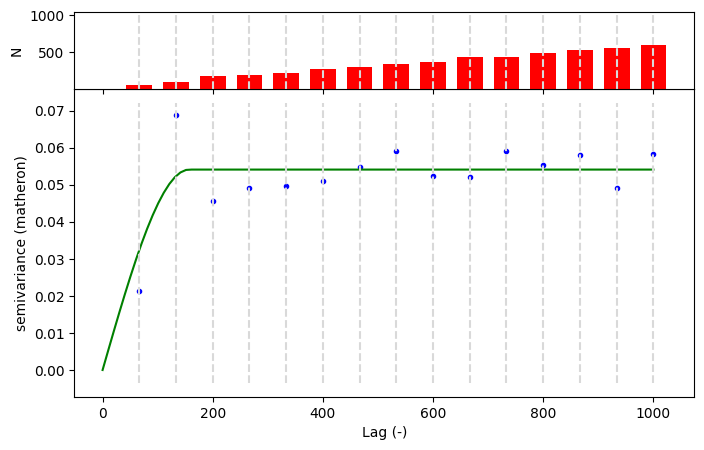

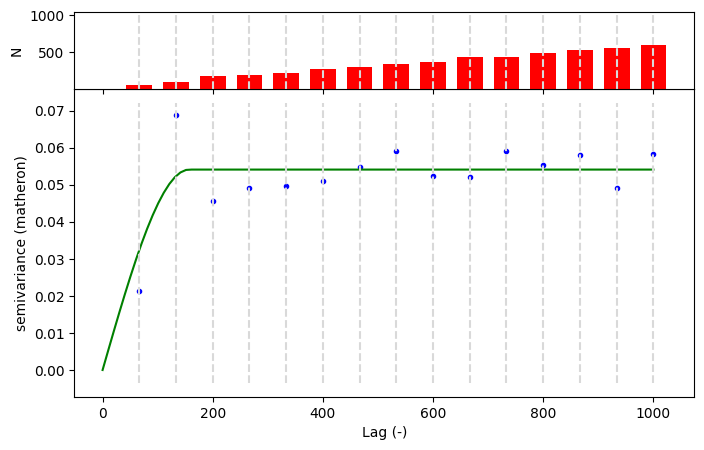

In [152]:

coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])

y_train_true = gdf_train['precio'].values
y_train_pred = model.predict(
        gdf_train
)
residuals = np.log(y_train_true) - np.log(y_train_pred)

V = Variogram(
    coords,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=1000,     # o una distancia en metros
    normalize=False
)
V.plot()

In [153]:
coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])
coords_test = np.column_stack([
    gdf_test.geometry.x,
    gdf_test.geometry.y
])
sill, range_, _ = V.parameters
nugget = 0.0002  
OK = OrdinaryKriging(
    coords[:,0],
    coords[:,1],
    gdf_train['precio'].values,
    variogram_model='gaussian',
    variogram_parameters=[sill, range_, nugget]
)
z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

In [154]:


rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    z_pred
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    z_pred
)

rmse, mae


(133902.45494043035, 78490.29799756421)

In [155]:
sill, range_, _ = V.parameters
nugget = 0.002  

OK = OrdinaryKriging(
    coords[:,0],
    coords[:,1],
    residuals,
    variogram_model="spherical",
    variogram_parameters=[sill, range_, nugget]
)

z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

y_test_pred_model_y_residual_kriging = y_test_pred + np.exp(z_pred)

In [156]:
print("z_pred stats:")
print("min:", z_pred.min())
print("max:", z_pred.max())
print("mean:", z_pred.mean())
print("std:", z_pred.std())

z_pred stats:
min: -0.5952147830858261
max: 0.8291047744174249
mean: 0.0011344451971112975
std: 0.13137506289393136


In [157]:

rmse = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
))

mae = mean_absolute_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
)

rmse, mae

(2098452.0460643275, 229272.53250953558)

In [158]:
(y_test_pred_model_y_residual_kriging <= 0).sum()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()

(47838.177726219736, 28347007.547169436)

Local outlier detection con Lisa

In [160]:
from esda.moran import Moran_Local
from libpysal.weights import KNN

gdf.to_crs(epsg=3857)

coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])


w = KNN.from_array(coords, k=8)
w.transform = "r"

y_true = gdf['precio'].values

model_global = SpatialKernelPriceModel(gdf)

model_global.fit(
    data=gdf,
)

y_pred = model_global.predict(
        gdf
)
residuals = y_true - y_pred
lisa = Moran_Local(residuals, w)


In [162]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))


In [163]:
gdf[outliers]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,valido_hasta,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes,tipo_inmueble_departamento,tipo_inmueble_ph
145,18875770,https://www.argenprop.com/departamento-en-vent...,89000.0,0.0,39.06,1 dorm.,5.000000,0,images/18875770.jpg,https://proxy.sosiva451.com/proxy/D32BD4C35AC5...,...,NaN,POINT (-6498946.532 -4116742.1),3.0,Barracas,4.0,2,2278.545827,19.530000,True,False
146,18875765,https://www.argenprop.com/ph-en-venta-en-barra...,74999.0,20000.0,68.00,3 dorm.,51.000000,0,images/18875765.jpg,https://proxy.sosiva451.com/proxy/CCE0C566569F...,...,NaN,POINT (-6499585.505 -4116443.039),3.0,Barracas,4.0,4,1102.926471,17.000000,False,True
230,18875971,https://www.argenprop.com/departamento-en-vent...,165000.0,301000.0,39.40,1 dorm.,4.000000,0,images/18875971.jpg,https://proxy.sosiva451.com/proxy/969DF6D03868...,...,NaN,POINT (-6506163.374 -4105352.278),20.0,Palermo,14.0,2,4187.817259,19.700000,True,False
359,15655177,https://www.argenprop.com/departamento-en-vent...,120000.0,0.0,43.00,1 dorm.,50.000000,0,images/15655177.jpg,https://proxy.sosiva451.com/proxy/3717FC3F661B...,...,NaN,POINT (-6507611.641 -4106952.999),8.0,Chacarita,15.0,2,2790.697674,21.500000,True,False
445,16583686,https://www.argenprop.com/departamento-en-vent...,310000.0,0.0,147.00,4 dorm.,40.000000,3200,images/16583686.jpg,https://proxy.sosiva451.com/proxy/38F4266DB676...,...,NaN,POINT (-6513775.401 -4109281.482),37.0,Villa Devoto,11.0,5,2108.843537,29.400000,True,False
482,18876832,https://www.argenprop.com/departamento-en-vent...,149000.0,55000.0,41.16,2 dorm.,70.000000,0,images/18876832.jpg,https://proxy.sosiva451.com/proxy/CEFDD6EF5EF4...,...,NaN,POINT (-6507777.507 -4106958.407),8.0,Chacarita,15.0,3,3620.019436,13.720000,True,False
633,12111548,https://www.argenprop.com/departamento-en-vent...,193770.0,0.0,61.00,2 dorm.,33.264706,0,images/12111548.jpg,https://proxy.sosiva451.com/proxy/289F29F0CF9A...,...,NaN,POINT (-6505120.311 -4106285.103),20.0,Palermo,14.0,3,3176.557377,20.333333,True,False


In [164]:
gdf_outliers = gdf[outliers]
gdf_outliers['precio_total'] = gdf_outliers['precio'] + gdf_outliers['expensas']
gdf_outliers.sort_values('precio_total')

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes,tipo_inmueble_departamento,tipo_inmueble_ph,precio_total
145,18875770,https://www.argenprop.com/departamento-en-vent...,89000.0,0.0,39.06,1 dorm.,5.000000,0,images/18875770.jpg,https://proxy.sosiva451.com/proxy/D32BD4C35AC5...,...,POINT (-6498946.532 -4116742.1),3.0,Barracas,4.0,2,2278.545827,19.530000,True,False,89000.0
146,18875765,https://www.argenprop.com/ph-en-venta-en-barra...,74999.0,20000.0,68.00,3 dorm.,51.000000,0,images/18875765.jpg,https://proxy.sosiva451.com/proxy/CCE0C566569F...,...,POINT (-6499585.505 -4116443.039),3.0,Barracas,4.0,4,1102.926471,17.000000,False,True,94999.0
359,15655177,https://www.argenprop.com/departamento-en-vent...,120000.0,0.0,43.00,1 dorm.,50.000000,0,images/15655177.jpg,https://proxy.sosiva451.com/proxy/3717FC3F661B...,...,POINT (-6507611.641 -4106952.999),8.0,Chacarita,15.0,2,2790.697674,21.500000,True,False,120000.0
633,12111548,https://www.argenprop.com/departamento-en-vent...,193770.0,0.0,61.00,2 dorm.,33.264706,0,images/12111548.jpg,https://proxy.sosiva451.com/proxy/289F29F0CF9A...,...,POINT (-6505120.311 -4106285.103),20.0,Palermo,14.0,3,3176.557377,20.333333,True,False,193770.0
482,18876832,https://www.argenprop.com/departamento-en-vent...,149000.0,55000.0,41.16,2 dorm.,70.000000,0,images/18876832.jpg,https://proxy.sosiva451.com/proxy/CEFDD6EF5EF4...,...,POINT (-6507777.507 -4106958.407),8.0,Chacarita,15.0,3,3620.019436,13.720000,True,False,204000.0
445,16583686,https://www.argenprop.com/departamento-en-vent...,310000.0,0.0,147.00,4 dorm.,40.000000,3200,images/16583686.jpg,https://proxy.sosiva451.com/proxy/38F4266DB676...,...,POINT (-6513775.401 -4109281.482),37.0,Villa Devoto,11.0,5,2108.843537,29.400000,True,False,310000.0
230,18875971,https://www.argenprop.com/departamento-en-vent...,165000.0,301000.0,39.40,1 dorm.,4.000000,0,images/18875971.jpg,https://proxy.sosiva451.com/proxy/969DF6D03868...,...,POINT (-6506163.374 -4105352.278),20.0,Palermo,14.0,2,4187.817259,19.700000,True,False,466000.0


In [71]:
gdf_ml = gdf_join.to_crs(epsg=4326).copy()

gdf_ml['lon'] = gdf_ml.geometry.x
gdf_ml['lat'] = gdf_ml.geometry.y

gdf_ml['log_precio'] = np.log(gdf_join['precio'])

In [72]:
features = [
    'lat', 'lon',
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

target = 'log_precio'

df = gdf_ml[features + [target]].copy()

# eliminar filas con target faltante
df = df.dropna(subset=[target])


In [73]:
from sklearn.impute import SimpleImputer

X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)


In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [372]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))


RF R2: 0.27286055025373324
RF MAE: 0.24327020958430484


In [373]:
import pandas as pd

pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)


area_m2       0.331118
expensas      0.169370
ambientes     0.135191
lat           0.130872
lon           0.124616
antiguedad    0.108834
dtype: float64

In [374]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [375]:
y_pred_xgb = xgb.predict(X_test)

print("XGB R2:", r2_score(y_test, y_pred_xgb))
print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))


XGB R2: 0.23715495166539946
XGB MAE: 0.2593276495625976
